# Learning Objectives

After reading this notebook, students should be able to

+ Explain the concept of Markov Processes and Markov Reward Processes

+ Solve the Bellman equations for small MRPs to determine the values of states 



# Pre-requisites

+ K-armed Bandits


# Markov Reward Processes

A Reinforcement Learning (RL) agent acts in an environment and learns from the feedback the environment gives back. In order to do this, we need a way to model the environment. Markov Processes are simple stochastic processes that we can extend to form a framework for RL problems.

In this chapter, we will look at what Markov Processes are. We will look at how some processes can be modelled as markov processes. Then, we will extend Markov processes with a notion of rewards. This extension is called a Markov Reward Process (MRP). Again, we will model some processes as MRPs.


### Markov Processes


Let's take a stochastic system for an example. The weather changes continuously with time, and there are an infinite number of states that the weather in a place can be in. For example, it can be overcast at 1 PM and then rainy an hour later. But we can simplify the weather by taking some discrete states it can be in some discrete time intervals. 

For now, let's model the weather as something that remains the same for the whole day. And, let's take a day as the size of our single discrete timestep. So, the state $S_t$ is the weather observed in the timestep $t$. Now, the state of our environment may depend on the entire history of the environment. That is, the probability that we will be at state $s$ at timestep $T+1$ is given by $\text{Pr}(S_{t+1}=s|S_{t}, S_{t-1}, ..., S_{1})$. 


A Markov process is a model of a sequence of events in which the probability of a future state depends only on the present state, and does not depend on past events. That is, all the information needed for us to evaluate the probability of a future state is part of the current state. This fact allows us to discard entire histories of a process, since the currents state has all the information we need from the history. 


If we assume that the weather is a Markov process, we can model the weather in a day so that it is dependent only on the weather in the previous day. That is, we go from modelling the weather as $\text{Pr}(S_{t+1}=s|S_{t}, S_{t-1}, ..., S_{1})$ into $\text{Pr}(S_{t+1}=s|S_{t})$. Notice how simple the probability is now? If we can somehow get all the information we need from the last state ($S_t$), we can discard the entire history of the environment.
 
In general, this property, that allows us to discard the history when the present state contains all the information we need to predict a future timestep, is called the Markov property. Due to its simplicity, many problems that involve sequences, like language generation and reinforcement learning, use the Markov property in modeling.


A Markov process has a state space, which is the set of all the states in the process. In our weather example, the states could be the weather in each day, such as rainy or sunny. In this case, the set of all possible weather types is the state space. We represent the state space of an environment by $S$.




$$S=\{\text{sunny}, \text{cloudy}, \text{rainy}\}$$


<div align="center">
    <figure>
<p>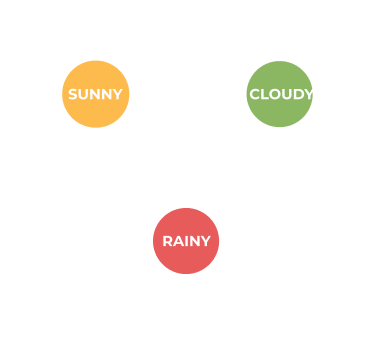</p>
     <figcaption>Figure 1: The state space for our weather environment is made of three states.</figcaption>
    </figure>
</div>

$\text{Pr}(S_{t+1}=s'|S_t=s)$ is called the transition probability from the state $s$ to the state $s'$. It is the probability that we will end up in state $s'$ in the next timestep if we are at state $s$ in the current timestep. 


In our weather example, let's say that you noted the weather for many days, and calculated the probabilities of each of these weather types given the weather in the last day. Your calculations brought you to the following conclusions:

1. If it's rainy today, there's 35% chance to rain, only 5% chance to be sunny and 60 % chance to be cloudy tomorrow.

$Pr(V_{t+1} = \text{rainy} | V_t = \text{rainy}) = 0.35, \\  
Pr(V_{t+1} = \text{sunny} | V_t = \text{rainy}) = 0.05, \\
Pr(V_{t+1} = \text{cloudy} | V_t = \text{rainy}) = 0.6$

2. If it's sunny today, there's 30% chance to rain, 40 % chance to be sunny and  30% chance to be cloudy tomorrow.

$Pr(V_{t+1} = \text{rainy} | V_t = \text{sunny}) = 0.3, \\    
Pr(V_{t+1} = \text{sunny} | V_t = \text{sunny}) = 0.4, \\    
Pr(V_{t+1} = \text{cloudy} | V_t = \text{sunny}) = 0.3$


3. If it's cloudy today, there's 70% chance to rain, 10 % chance to be sunny and 20% chance to be cloudy tomorrow.

$Pr(V_{t+1} = \text{rainy} | V_t = \text{cloudy}) = 0.7, \\    
Pr(V_{t+1} = \text{sunny} | V_t = \text{cloudy}) = 0.1, \\    
Pr(V_{t+1} = \text{cloudy} | V_t = \text{cloudy}) = 0.2$ 

<div align="center">
    <figure>
<p>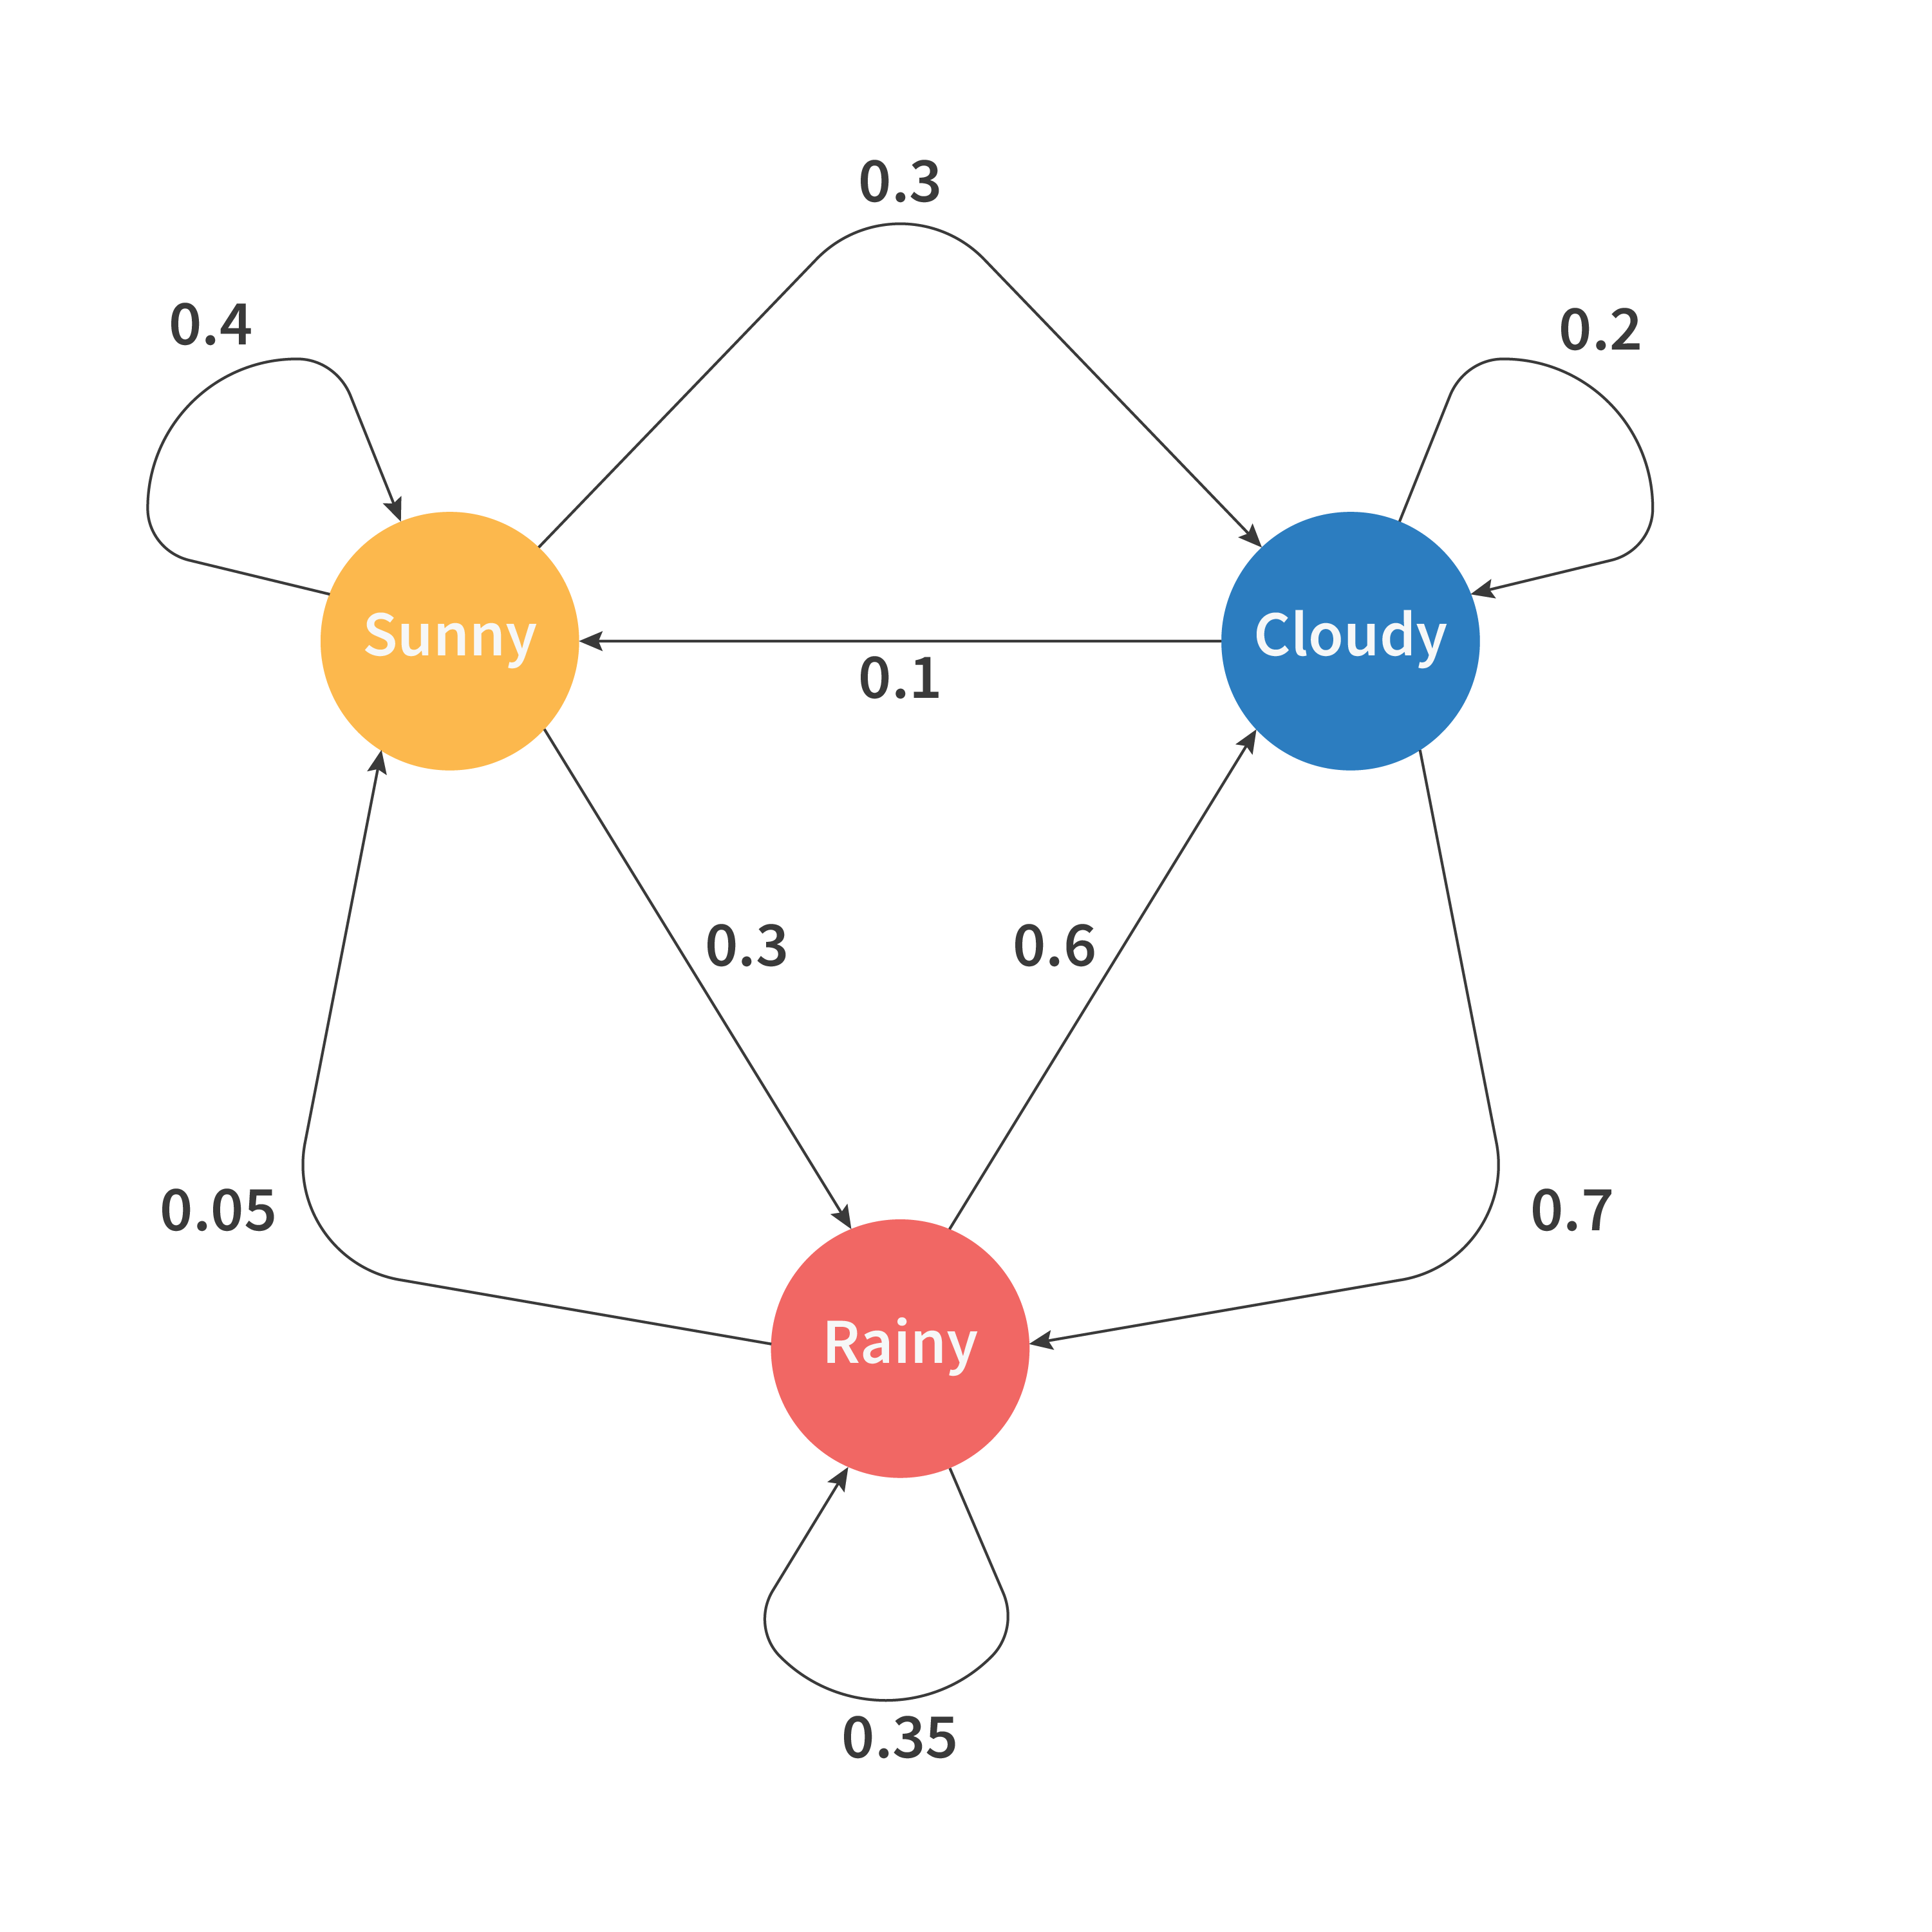</p>
     <figcaption>Figure 2: The transition probabilities for the weather environment.</figcaption>
    </figure>
</div>




In each step that you are in right now, there are $|S|$ different steps you can end up in the next timestep. So, for each of the $|S|$ different states, there are $|S|$ different probabilities governing where you will end up at next. We can stack the transition probabilities for each state in a matrix of size $|S| \times |S|$. This matrix is called the transition probability matrix of the Markov process, and we denote it using the letter $P$. 


$$
P = 
\begin{bmatrix}
0.35 & 0.6 & 0.05 \\
0.3  & 0.4  & 0.3 \\
0.7 & 0.1 & 0.2 \\
\end{bmatrix}
$$


The element $P_{ij}$ of this matrix is the probability that you will end up at state $j$ if you are in the state $i$ in the current timestep. 


To review, a Markov process as two distinct components: a state space $S$, and a transition probability function $\text{Pr}(s'|s)$, which we also represent as a matrix $P$. The probability that we will end up at state B in the next time step, if we are in state A in the current timestep, is given be $\text{P}(B|A)$, and is independent of which states we visited before state A. This is called the Markov property. 


The trajectory of a Markov Process is made of a sequence of states. That is, its a sequence of the state of the environment in each timestep. $$\text{trajectory of a Markov process} \rightarrow \{S_1, S_2, ... , S_T\}$$


### Markov Reward Processes

Now, we will extend Markov processes into Markov Reward Processes (MRPs). 

MRPs work in the same way as normal Markov processes, but when you get to a state, you get a feedback from the environment. This feedback is a scalar value that tells us how good a particular state is. In Reinforcement Learning, this feedback is known as a reward. 

Take the environment we looked at in the previous section. Say that you have a solar panel on your roof that generates a centain amount of energy during the day. This energy is a measurable feedback from the environment. The energy generated by the solar panel during the day differs with the weather in that day. For example, a full day of sun might result in a lot more power generation than a day with heavy rain the whole time. 

<div align="center">
    <figure>
<p>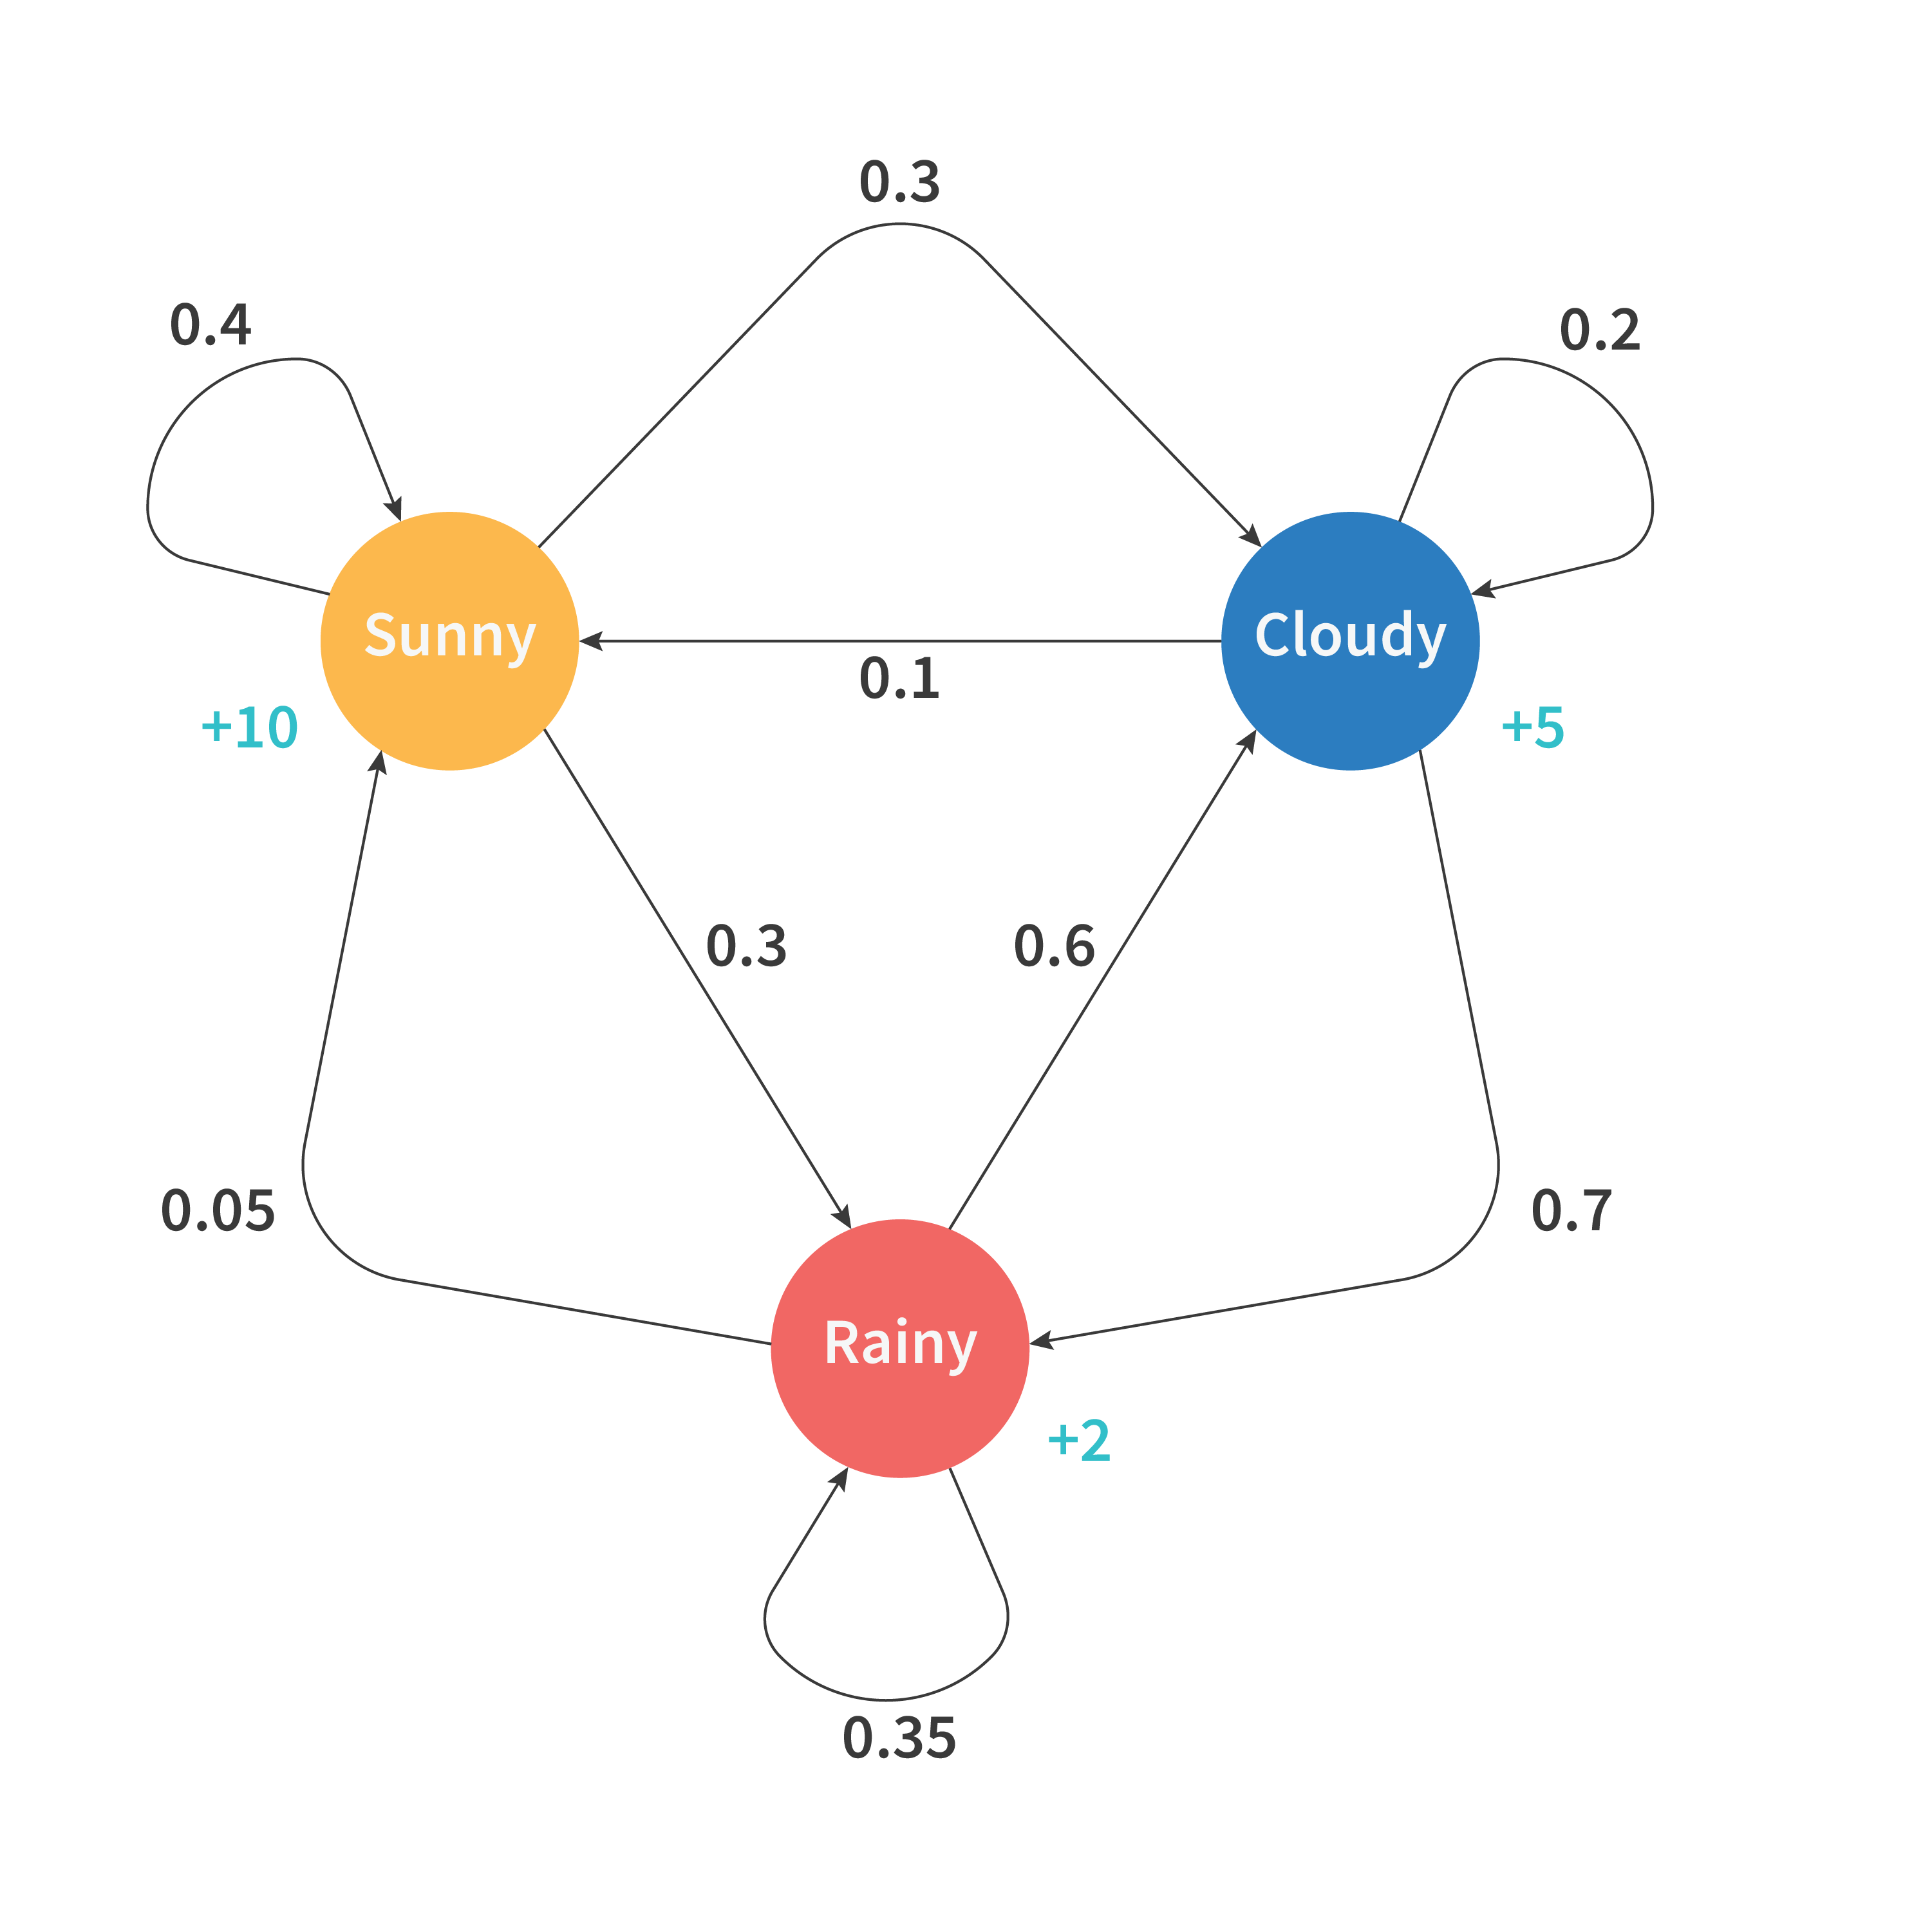</p>
     <figcaption>Figure 3: The numbers in blue show the average electricty generated by a solar panel during each type of weather. They can be treated as rewards for each state.</figcaption>
    </figure>
</div>


The usual trajectory for a Markov process is $S_1, S_{2}, S_{3}, ..., S_{T}$. Markov reward processes are just the same, but with a reward that you get at the end of a timestep. That is, the general trajectory for an MRP is given by $S_1, R_2, S_2, R_3, S_3, ..., S_T, R_{T+1}, S_{T+1}$. Note that $R_1$ does not appear in the trajectory. When we transition from the timestep $T$ to $T+1$, the reward that we get is $R_{T+1}$. This is to signify that we get the reward $R_{T+1}$ and transition to state $S_{T+1}$ simultaneously.  


The reward function of a state, which we will denote by $R(s)$, is given by $R(s) = \mathbb{E}[R_{T+1}|S_t=s]$. That is, the reward function of a state $s$ is the average reward you get when you transition from $s$ to some other state. 


#### Returns

In Reinforcement Learning, we try to maximise the total rewards that an agent gets. This concept of the total reward is called the return, which we denote by the letter $G$. The return in a timestep is the sum of the rewards that you get from the future states. If you are in a cetrain state in timestep $t$, the return for that state is the sum of the future rewards.

$$G_t = R_{t+1} + R_{t+2} + \dots + R_{T}$$

Here, $T$ is some final timestep. Some environments may have a definite final state, or maybe even more than one. For example, in a game of Snake and Laddars, once you reach the $100^{th}$ cell, the game terminates. Some don't, like the weather environment example we are using in this notebook. 

In practice though, we use another form of return more often than this version based on naive sum. Instead of summing the individual rewards, we give each of them a weight that decreases exponentially as you move forward in time:

$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} \dots$$


$\gamma$ is a number that lies between 0 and 1, and it is also called the discount factor. 

This formulation of the return has a number of characterstics. 

* The rewards you get from the later timesteps are multiplied by an increasingly small constant. Therefore, the rewards from later timesteps are given small weights when calculating the return for a state. 

* The sum $G_t$ does not blow up to infinity if the MRP is infinitely long. This is because the $\gamma^K$ terms grow exponentially smaller, and when multiplied by finite $R$'s, result in a finite sum in $G$. 

* The fact that the $\gamma^K$ term grows smaller for future timesteps means that we favor more immediate rewards over getting the same reward in a distant timestep. It is natural to think of this way, since even in real life, we tend to favor immediate feedbacks over long term ones. 


### Value of a state

Another concept that is fundamental to RL is that of value functions. The value function of a state is a number that denotes how good that state is. The 'goodness' of a state is given by the returns that you can expect to get from that state. So, if a state has a high average return, the value of that state is also high. The opposite is also true, i.e., if the average return from a state is low, the value of that state is low too. 

This brings us to define the value function for a state. For an MRP, we use the average returns from a state as its value. So, the value $V(s)$ of a state $s$ is the average return you can expect from that state. 


$$V(s) = E[G_t|S=s]$$


We can conveniently decompose the value of a state $s$ into two constituents: the immediate reward $R_s$ we get from the state, and the discounted value of the next state. 


$$
\begin{align}
V(s) &= E[G_t|S_t=s]
\\
&= E[R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots|S_t=s]
\\
&= E[R_{t+1} + \gamma (R_{t+2} + \gamma R_{t+3} + \dots)|S_t=s]
\\
&= E[R_{t+1} + \gamma G_{t+1}|S_t=s]
\\
&= E[R_{t+1} + \gamma V(s')|S_t=s]
\end{align}
$$


To make things more explicit, let's write the terms as sums instead of expectations.

$$
V(s) =R_s+\gamma \sum_{s'∈S}P_{ss'} V(s')
$$
where, $P_{ss'}$ is the state transition probability defined by
$$P_{ss'} = P[S_{t+1}=s'|S_t=s]$$


This is the Bellman equation for a state $s$ in an MRP. The Bellman equation gives us a equation for each state in our environment. Each of these equations are linear in the state values, i.e., the $V(s)$ terms. So, solving these linear equations gives us the value functions for each state in the MRP. 


#### Solving the Bellman Equations

Because the Bellman equations are simple linear equations, we can solve them using any of the computational techniques that exist for solving linear equations. For now, let's represent the Bellman equations as a single linear equation using matrices. 

$$
v = R + \gamma P v
$$

Here, $v$ is a vector formed by stacking the value functions for each state. $R$ is a vector that contains the average immediate reward associated with each state, and $P$ is the transition probability matrix. We can manipulate this equation algebraically and solve for $v$.

$$
\begin{align}
v &= R + \gamma P v\\
v - \gamma P v &= R\\
v &= (1 - \gamma P)^{-1} R
\end{align}
$$


The resulting vector $v$ contains the value functions for all the states in the MRP.


## Key Takeaways

+ Markov Processes are stochastic processes that follow the Markov property. 

+ Markov Reward Processes are MRPs that have a notion of reward in each timestep. 

+ The states in an MRP have values, which measure the cumulative reward you can expect from the future states if you start out at a particular state.

+ The value of a state can be decomposed into the immediate reward, and the expected return of the other states. This gives rise to the Bellman equations.

+ Solving the Bellman equations gives us the value function of each state. 


## References

* Reinforcement Learning: An Introduction by *Richard S. Sutton* and *Andrew G. Barto*
